In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('✅ Setup complete')

✅ Setup complete


In [2]:
train = pd.read_csv('/kaggle/input/datasets/kvenkatanandakumar/prediction/data/train.csv')
test  = pd.read_csv('/kaggle/input/datasets/kvenkatanandakumar/prediction/data/test.csv')

print(f'Train: {train.shape}  |  Test: {test.shape}')
train.head(3)

Train: (1460, 81)  |  Test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


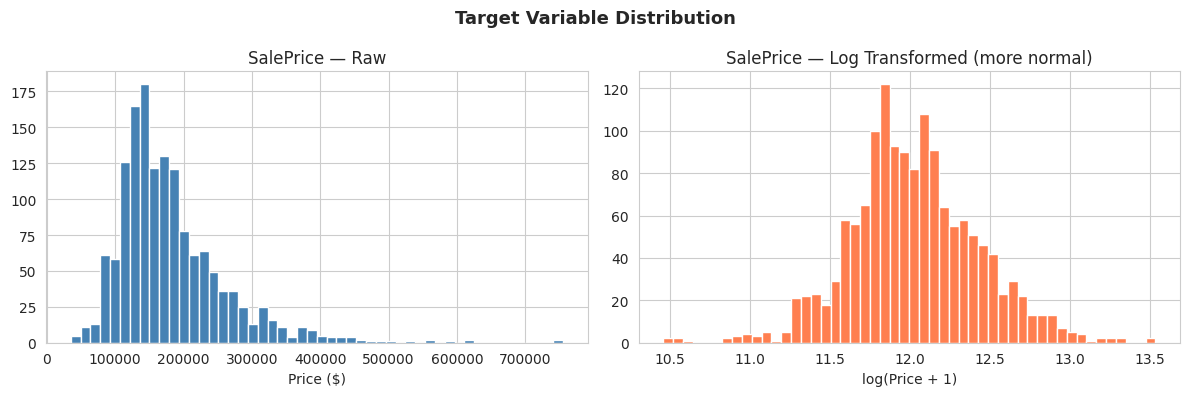

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


In [3]:
# --- 3.1 Target Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice — Raw')
axes[0].set_xlabel('Price ($)')

axes[1].hist(np.log1p(train['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('SalePrice — Log Transformed (more normal)')
axes[1].set_xlabel('log(Price + 1)')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(train['SalePrice'].describe().round(0))

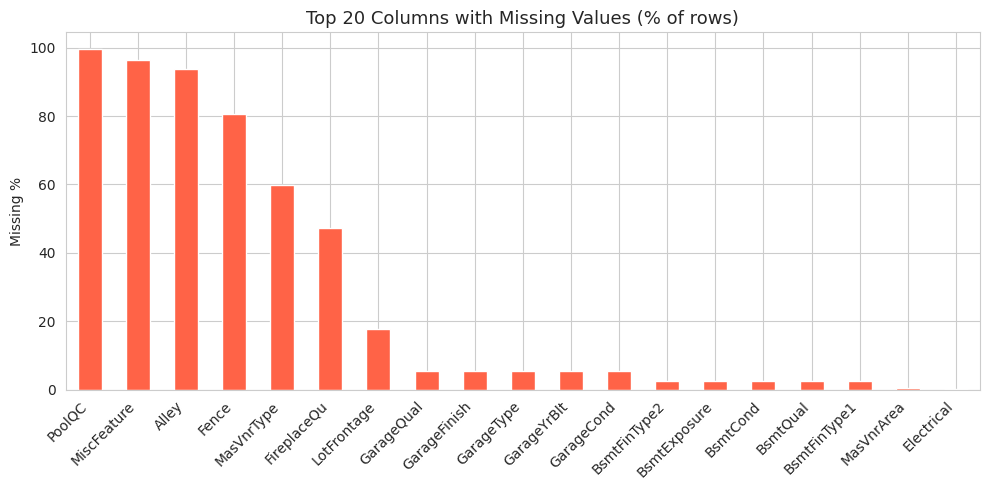

Total columns with missing values: 19


In [4]:
# --- 3.2 Missing Values Heatmap ---
missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing = missing[missing > 0].head(20)

plt.figure(figsize=(10, 5))
missing.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Top 20 Columns with Missing Values (% of rows)', fontsize=13)
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Total columns with missing values: {(train.isnull().sum() > 0).sum()}')

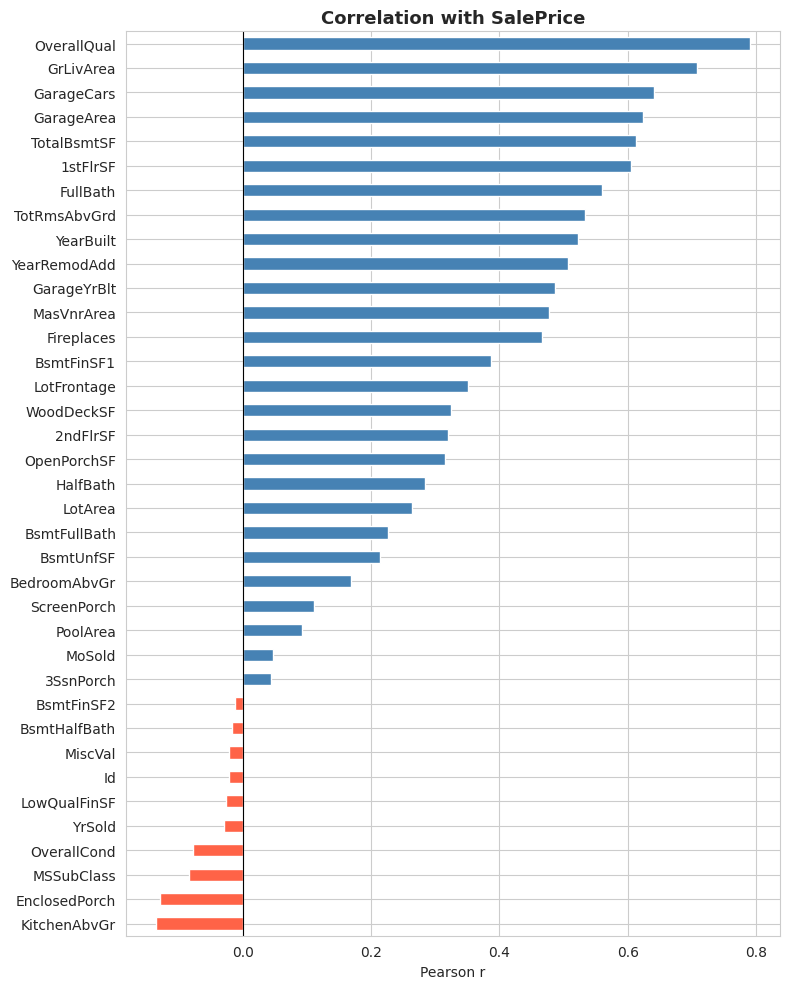

In [5]:
# --- 3.3 Correlation: Numeric Features vs SalePrice ---
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[numeric_cols].corr()['SalePrice'].drop('SalePrice').sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr.values]
corr.plot(kind='barh', color=colors, ax=ax, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation with SalePrice', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

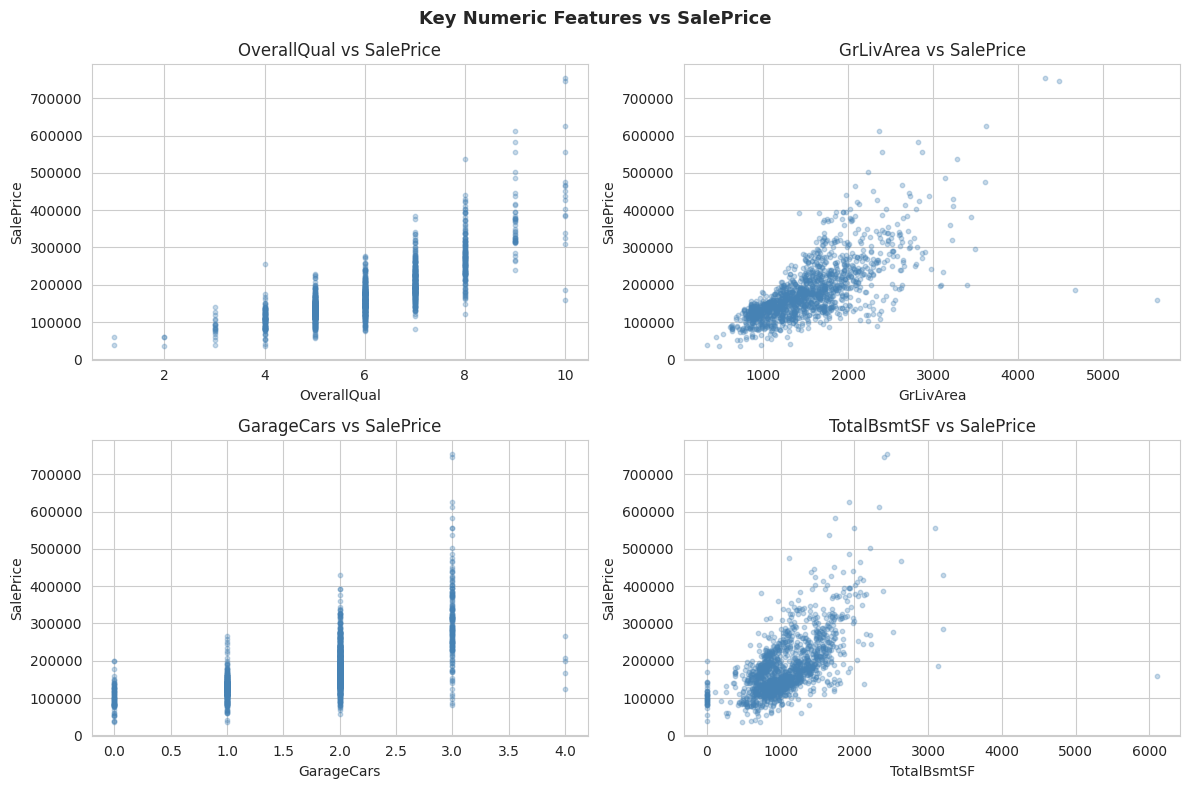

In [6]:
# --- 3.4 Top Features Scatter Plot ---
top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), top_features):
    ax.scatter(train[feat], train['SalePrice'], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{feat} vs SalePrice')

plt.suptitle('Key Numeric Features vs SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

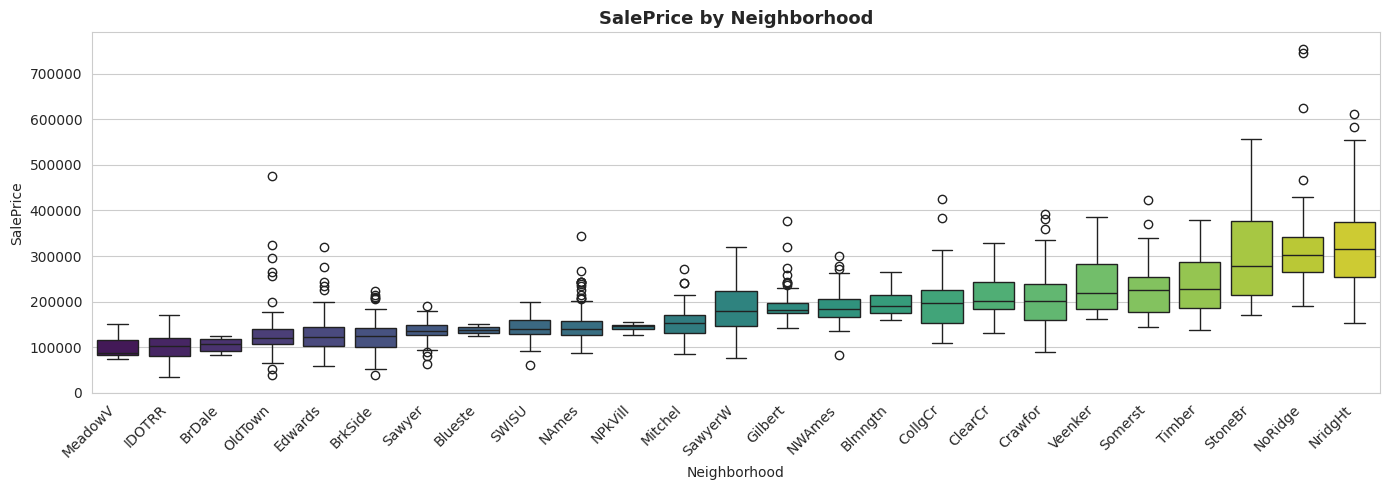

In [7]:
# --- 3.5 Sale Price by Neighborhood ---
plt.figure(figsize=(14, 5))
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(data=train, x='Neighborhood', y='SalePrice', order=order, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('SalePrice by Neighborhood', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Save target & IDs before combining
y = np.log1p(train['SalePrice'])          # Log-transform target
test_ids = test['Id']

# Combine for consistent preprocessing
all_data = pd.concat([train.drop(['SalePrice', 'Id'], axis=1),
                      test.drop('Id', axis=1)],
                     ignore_index=True)
print(f'Combined shape: {all_data.shape}')

Combined shape: (2919, 79)


In [9]:
# ── 4.1 Fill Missing Values ──────────────────────────────────────────────

# Categorical columns where NA means "None / No feature"
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

# Numeric columns where NA means 0
zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

# LotFrontage: fill with median per neighborhood
all_data['LotFrontage'] = (
    all_data.groupby('Neighborhood')['LotFrontage']
            .transform(lambda x: x.fillna(x.median()))
)

# Remaining categorical → mode
for col in all_data.select_dtypes(include='object').columns:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# Remaining numeric → 0
all_data = all_data.fillna(0)

print(f'Missing after fill: {all_data.isnull().sum().sum()}')

Missing after fill: 0


In [10]:
# ── 4.2 Feature Engineering ─────────────────────────────────────────────

# Total area
all_data['TotalSF']      = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
# House age & remodel age
all_data['HouseAge']     = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodelAge']   = all_data['YrSold'] - all_data['YearRemodAdd']
# Total bathrooms
all_data['TotalBath']    = (all_data['FullBath']
                            + 0.5 * all_data['HalfBath']
                            + all_data['BsmtFullBath']
                            + 0.5 * all_data['BsmtHalfBath'])
# Total porch area
all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['EnclosedPorch']
                            + all_data['3SsnPorch'] + all_data['ScreenPorch'])

print('✅ Engineered features: TotalSF, HouseAge, RemodelAge, TotalBath, TotalPorchSF')

✅ Engineered features: TotalSF, HouseAge, RemodelAge, TotalBath, TotalPorchSF


In [11]:
# ── 4.3 Encode Categorical Columns ──────────────────────────────────────

le = LabelEncoder()
for col in all_data.select_dtypes(include='object').columns:
    all_data[col] = le.fit_transform(all_data[col].astype(str))

print(f'Final feature matrix shape: {all_data.shape}')
print(f'All dtypes numeric: {(all_data.dtypes != object).all()}')

Final feature matrix shape: (2919, 84)
All dtypes numeric: True


In [12]:
# ── 4.4 Split Back into Train / Test ────────────────────────────────────
n_train = len(train)
X       = all_data.iloc[:n_train].values
X_test  = all_data.iloc[n_train:].values

print(f'X (train): {X.shape}  |  X_test: {X_test.shape}  |  y: {y.shape}')

X (train): (1460, 84)  |  X_test: (1459, 84)  |  y: (1460,)


In [13]:
def rmse_cv(model, X, y, cv=5):
    """Return mean & std RMSE from cross-validation (on log scale)."""
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = -cross_val_score(model, X, y,
                              scoring='neg_root_mean_squared_error', cv=kf)
    return scores.mean(), scores.std()

results = {}

In [14]:
# ── 5.1 Ridge Regression ────────────────────────────────────────────────
ridge = Ridge(alpha=10)
m, s = rmse_cv(ridge, X, y)
results['Ridge'] = (m, s)
print(f'Ridge       RMSE: {m:.4f}  ± {s:.4f}')

Ridge       RMSE: 0.1592  ± 0.0440


In [15]:
# ── 5.2 Lasso Regression ────────────────────────────────────────────────
lasso = Lasso(alpha=0.0005, max_iter=10000)
m, s = rmse_cv(lasso, X, y)
results['Lasso'] = (m, s)
print(f'Lasso       RMSE: {m:.4f}  ± {s:.4f}')

Lasso       RMSE: 0.1600  ± 0.0433


In [16]:
# ── 5.3 Random Forest ───────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                           min_samples_leaf=2, random_state=42, n_jobs=-1)
m, s = rmse_cv(rf, X, y)
results['RandomForest'] = (m, s)
print(f'RandomForest RMSE: {m:.4f}  ± {s:.4f}')

RandomForest RMSE: 0.1421  ± 0.0187


In [17]:
# ── 5.4 Gradient Boosting ───────────────────────────────────────────────
gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                max_depth=4, min_samples_leaf=5,
                                subsample=0.8, random_state=42)
m, s = rmse_cv(gbm, X, y)
results['GradientBoosting'] = (m, s)
print(f'GradBoost   RMSE: {m:.4f}  ± {s:.4f}')

GradBoost   RMSE: 0.1324  ± 0.0222


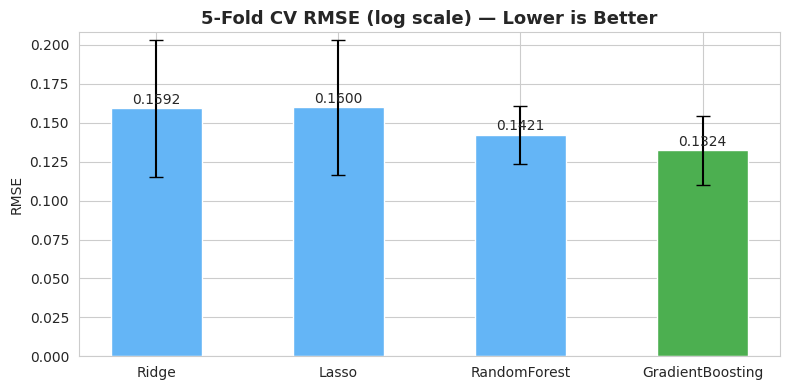


🏆 Best model: GradientBoosting  (RMSE = 0.1324)


In [18]:
# ── 5.5 Results Summary Chart ───────────────────────────────────────────
names  = list(results.keys())
means  = [results[n][0] for n in names]
stds   = [results[n][1] for n in names]

colors = ['#4CAF50' if m == min(means) else '#64B5F6' for m in means]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_title('5-Fold CV RMSE (log scale) — Lower is Better', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE')
ax.set_ylim(0, max(means) * 1.3)
plt.tight_layout()
plt.show()

best_model_name = min(results, key=lambda k: results[k][0])
print(f'\n🏆 Best model: {best_model_name}  (RMSE = {results[best_model_name][0]:.4f})')

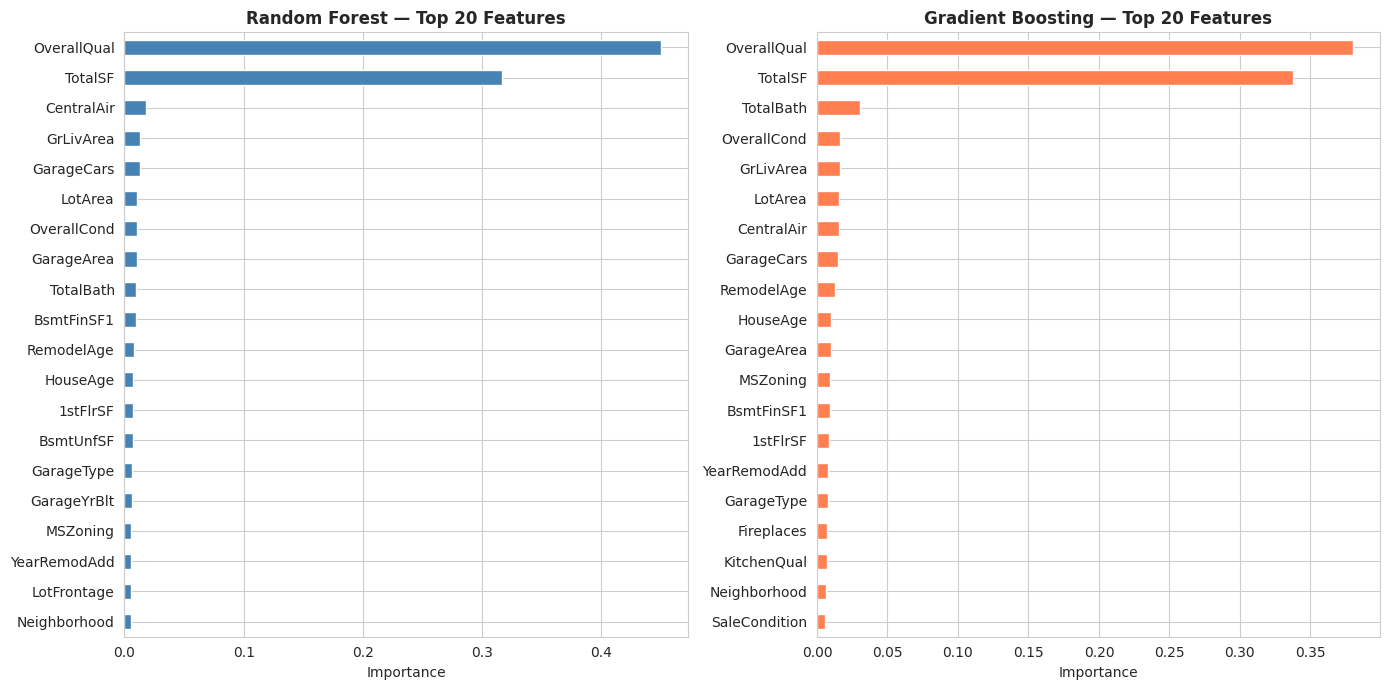

In [19]:
# Train RF and GBM on full training set for feature importance
feature_names = all_data.columns.tolist()

rf.fit(X, y)
gbm.fit(X, y)

rf_imp  = pd.Series(rf.feature_importances_,  index=feature_names).sort_values(ascending=False).head(20)
gbm_imp = pd.Series(gbm.feature_importances_, index=feature_names).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

rf_imp.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Random Forest — Top 20 Features', fontweight='bold')

gbm_imp.sort_values().plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Gradient Boosting — Top 20 Features', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [20]:
# Use best model (GBM — already fitted above)
# Ridge / Lasso need refitting on full data first
best_models = {
    'Ridge':           ridge,
    'Lasso':           lasso,
    'RandomForest':    rf,
    'GradientBoosting': gbm,
}

# Refit linear models on full training data
ridge.fit(X, y)
lasso.fit(X, y)

# Simple ensemble: average of all 4 predictions
preds = np.column_stack([
    ridge.predict(X_test),
    lasso.predict(X_test),
    rf.predict(X_test),
    gbm.predict(X_test),
])
ensemble_pred = preds.mean(axis=1)

# Reverse log transform
final_pred = np.expm1(ensemble_pred)

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_pred
})
submission.to_csv('submission.csv', index=False)
print('✅ Saved submission.csv')
submission.head(10)

✅ Saved submission.csv


,Id,SalePrice
0,1461,119469.402876
1,1462,159229.932693
2,1463,172737.688042
3,1464,189715.831005
4,1465,185818.909306
5,1466,174853.107049
6,1467,181542.575538
7,1468,170194.644806
8,1469,188590.236822
9,1470,121231.626589


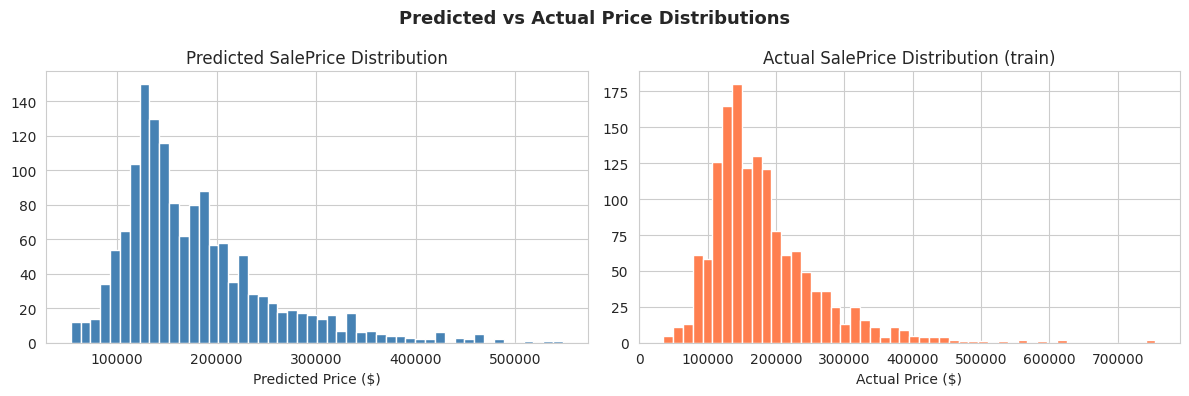


Prediction stats:
count      1459.0
mean     177056.0
std       73590.0
min       53413.0
25%      126483.0
50%      156248.0
75%      207748.0
max      547928.0
dtype: float64


In [21]:
# Distribution of predicted prices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(final_pred, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Predicted SalePrice Distribution')
axes[0].set_xlabel('Predicted Price ($)')

axes[1].hist(train['SalePrice'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Actual SalePrice Distribution (train)')
axes[1].set_xlabel('Actual Price ($)')

plt.suptitle('Predicted vs Actual Price Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nPrediction stats:')
print(pd.Series(final_pred).describe().round(0))

In [22]:
import joblib

# Save the trained GBM model
joblib.dump(gbm, "gbm_model.pkl")

# Save with compression (smaller file)
joblib.dump(gbm, "gbm_model.pkl", compress=3)

['gbm_model.pkl']